<center><h1>Основы глубокого обучения</h1></center>

# Домашнее задание 5: Обучение и визуализация трансформера

## Цель задания
1. Обучить простую модель трансформера для обработки изображений (Vision Transformer на MNIST)
2. Визуализировать веса внимания и интерпретировать их
3. Сделать выводы о том, как модель воспринимает данные

In [13]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cpu')

## Подготовка данных

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_subset = Subset(train_data, list(range(8000)))
test_subset = Subset(test_data, list(range(2000)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

print(f'Обучение: {len(train_subset)} примеров')
print(f'Тест: {len(test_subset)} примеров')

Обучение: 8000 примеров
Тест: 2000 примеров


## Vision Transformer

In [15]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.projection = nn.Conv2d(
            in_channels, embed_dim, 
            kernel_size=patch_size, 
            stride=patch_size
        )
    
    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.attn_weights = None
    
    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, attn_w = self.attn(x_norm, x_norm, x_norm)
        self.attn_weights = attn_w
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=28, patch_size=4, in_channels=1,
                 num_classes=10, embed_dim=64, num_heads=4,
                 num_layers=3, mlp_dim=256, dropout=0.1):
        super().__init__()
        
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed, std=0.02)
        
        self.pos_drop = nn.Dropout(dropout)
        
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self.all_attn_weights = []
    
    def forward(self, x):
        B = x.shape[0]
        
        x = self.patch_embed(x)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        
        self.all_attn_weights = []
        for block in self.transformer_blocks:
            x = block(x)
            self.all_attn_weights.append(block.attn_weights)
        
        x = self.norm(x)
        x = self.head(x[:, 0])
        return x

model = VisionTransformer(
    img_size=28, patch_size=4, in_channels=1,
    num_classes=10, embed_dim=64, num_heads=4,
    num_layers=3, mlp_dim=256, dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Всего параметров: {total_params:,}')

Всего параметров: 155,082


## Обучение модели

In [16]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()

train_losses = []
train_accs = []
test_losses = []
test_accs = []

def train_epoch():
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(train_loader), 100 * correct / total

def evaluate():
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(test_loader), 100 * correct / total

print('Начало обучения...')
for epoch in range(10):
    train_loss, train_acc = train_epoch()
    test_loss, test_acc = evaluate()
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f'Эпоха {epoch+1:2d} | Train: Loss={train_loss:.4f}, Acc={train_acc:6.2f}% | Test: Loss={test_loss:.4f}, Acc={test_acc:6.2f}%')

print(f'\nИтоговая точность на тесте: {test_accs[-1]:.2f}%')

Начало обучения...
Эпоха  1 | Train: Loss=1.8521, Acc= 32.41% | Test: Loss=1.4373, Acc= 47.05%
Эпоха  2 | Train: Loss=1.2113, Acc= 56.89% | Test: Loss=1.0150, Acc= 62.50%
Эпоха  3 | Train: Loss=0.8117, Acc= 72.12% | Test: Loss=0.7722, Acc= 74.60%
Эпоха  4 | Train: Loss=0.6137, Acc= 79.75% | Test: Loss=0.6618, Acc= 78.70%
Эпоха  5 | Train: Loss=0.4956, Acc= 84.17% | Test: Loss=0.5552, Acc= 82.20%
Эпоха  6 | Train: Loss=0.4126, Acc= 86.59% | Test: Loss=0.4850, Acc= 85.00%
Эпоха  7 | Train: Loss=0.3556, Acc= 88.34% | Test: Loss=0.4370, Acc= 85.20%
Эпоха  8 | Train: Loss=0.3184, Acc= 89.75% | Test: Loss=0.4167, Acc= 86.65%
Эпоха  9 | Train: Loss=0.2895, Acc= 91.11% | Test: Loss=0.4006, Acc= 86.60%
Эпоха 10 | Train: Loss=0.2666, Acc= 91.64% | Test: Loss=0.3862, Acc= 86.85%

Итоговая точность на тесте: 86.85%


## Визуализация обучения

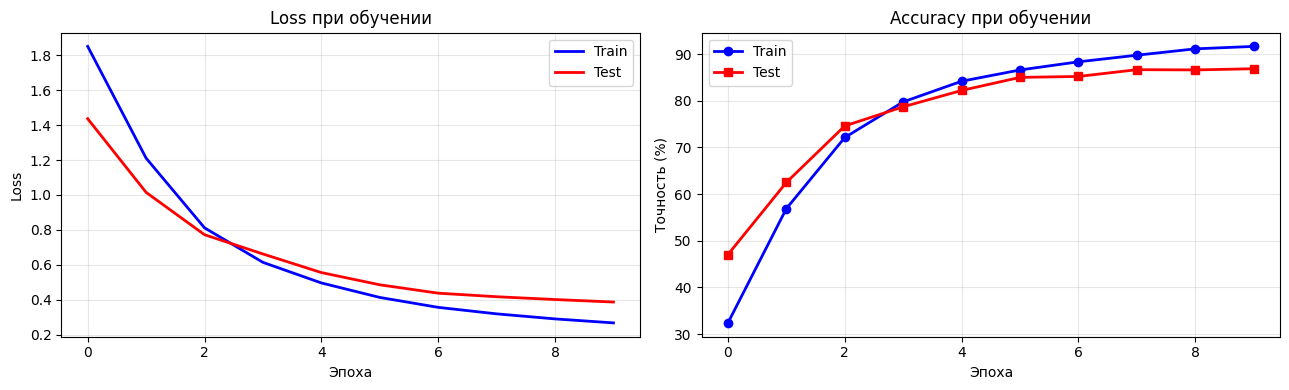

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, 'b-', label='Train', linewidth=2)
ax1.plot(test_losses, 'r-', label='Test', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Loss при обучении')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, 'b-', label='Train', linewidth=2, marker='o')
ax2.plot(test_accs, 'r-', label='Test', linewidth=2, marker='s')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Точность (%)')
ax2.set_title('Accuracy при обучении')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Анализ весов внимания на примерах

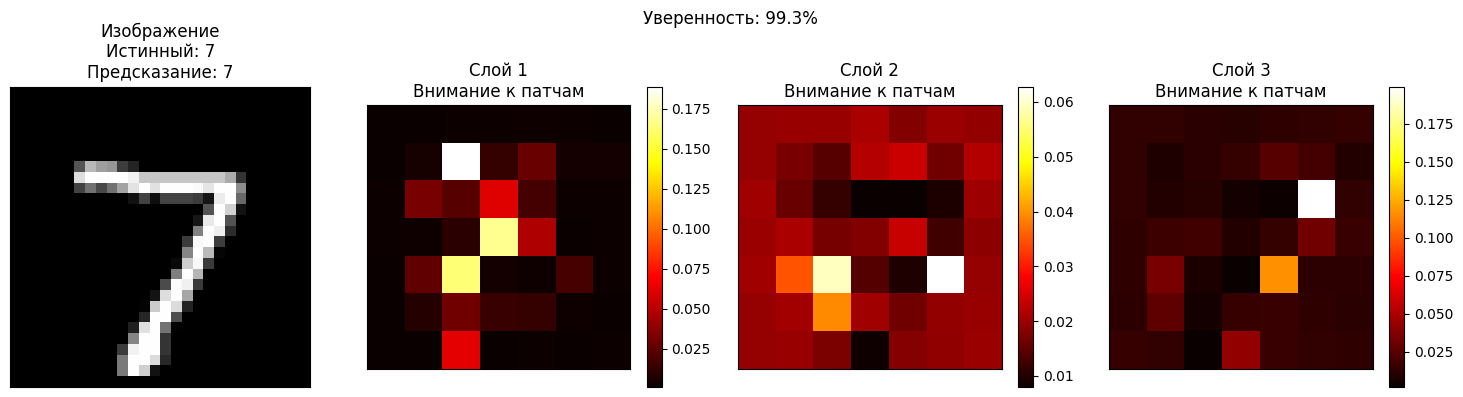

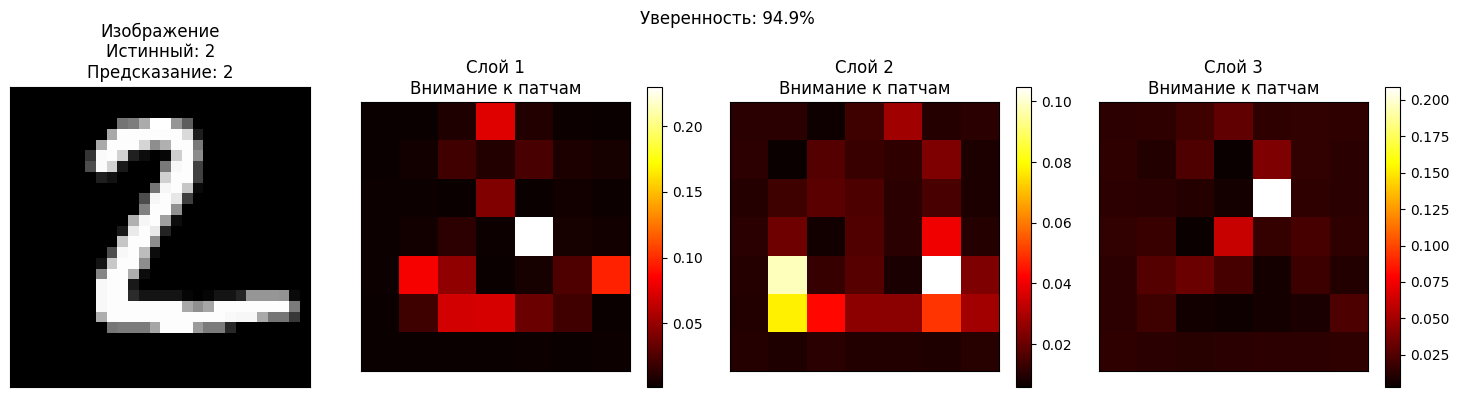

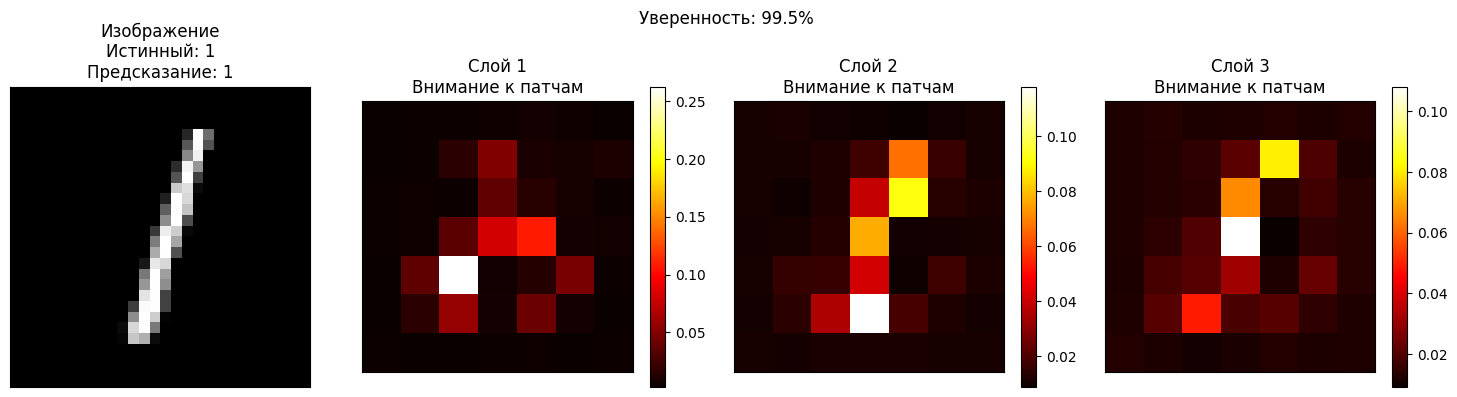

In [22]:
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    outputs = model(test_images)
    predictions = torch.argmax(outputs, dim=1)

for sample_idx in range(3):
    img = test_images[sample_idx, 0].cpu().numpy()
    true_label = test_labels[sample_idx].item()
    pred_label = predictions[sample_idx].item()
    confidence = F.softmax(outputs[sample_idx], dim=0).max().item()
    
    fig = plt.figure(figsize=(15, 4))
    grid_size = 7
    
    # Исходное изображение
    ax = plt.subplot(1, 4, 1)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Изображение\nИстинный: {true_label}\nПредсказание: {pred_label}')
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Три слоя внимания
    for layer_idx in range(min(3, len(model.all_attn_weights))):
        ax = plt.subplot(1, 4, layer_idx + 2)
        attn = model.all_attn_weights[layer_idx]
        # attn имеет форму (batch, seq_len, seq_len)
        attn_weights = attn[sample_idx, 0, 1:].cpu().numpy()
        attn_grid = attn_weights.reshape(grid_size, grid_size)
        
        im = ax.imshow(attn_grid, cmap='hot')
        ax.set_title(f'Слой {layer_idx + 1}\nВнимание к патчам')
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax)
    
    fig.suptitle(f'Уверенность: {confidence:.1%}', fontsize=12)
    plt.tight_layout()
    plt.show()

## Интегрированная визуализация по слоям

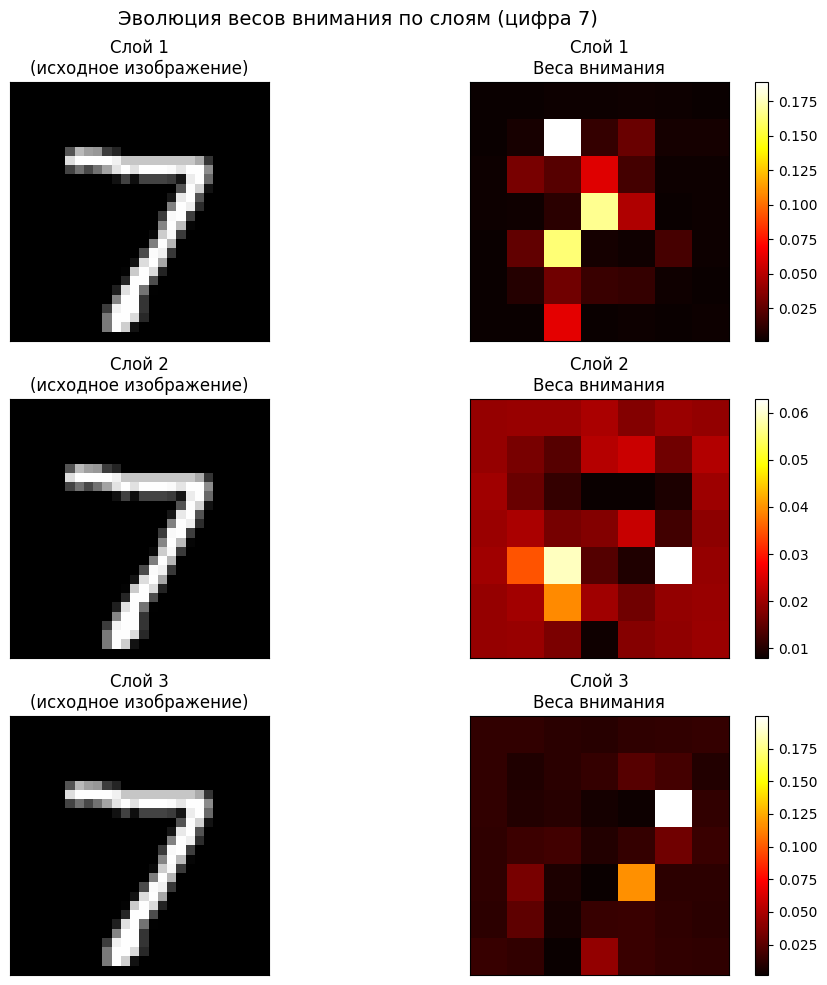

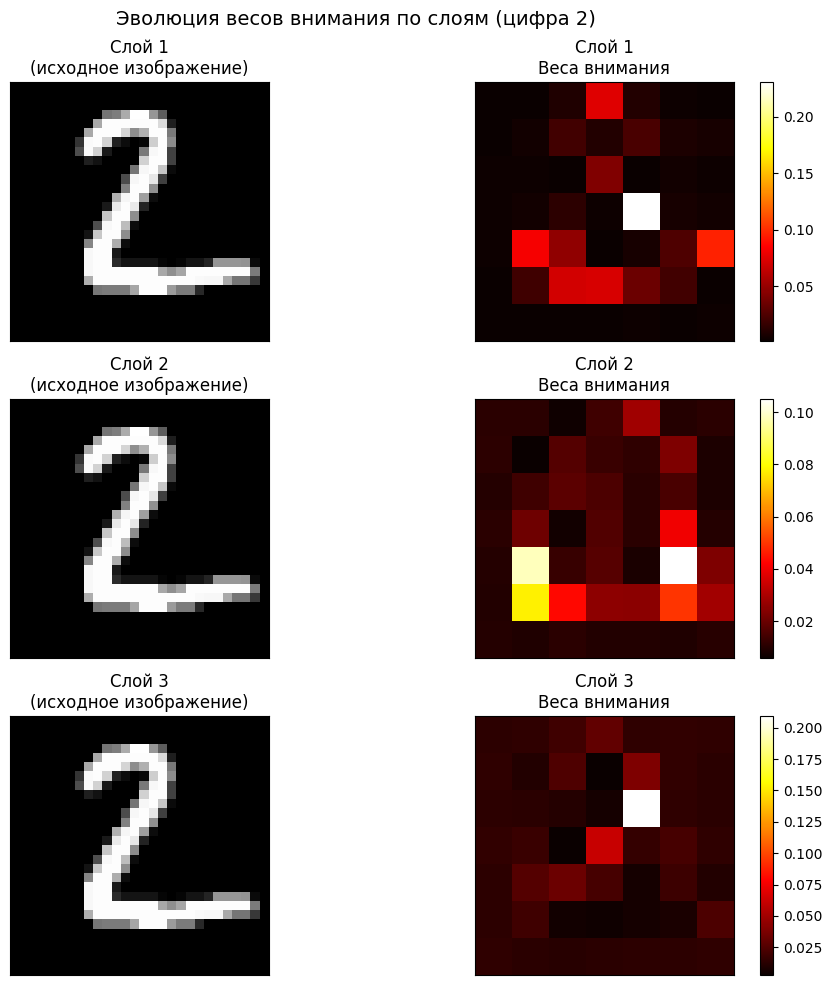

In [23]:
def visualize_attention_evolution(sample_idx=0):
    test_images, test_labels = next(iter(test_loader))
    test_img = test_images[sample_idx].unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(test_img)
    
    img = test_images[sample_idx, 0].numpy()
    num_layers = len(model.all_attn_weights)
    
    fig, axes = plt.subplots(num_layers, 2, figsize=(10, 10))
    
    for layer_idx in range(num_layers):
        axes[layer_idx, 0].imshow(img, cmap='gray')
        axes[layer_idx, 0].set_title(f'Слой {layer_idx + 1}\n(исходное изображение)')
        axes[layer_idx, 0].set_xticks([])
        axes[layer_idx, 0].set_yticks([])
        
        attn = model.all_attn_weights[layer_idx]
        # attn имеет форму (batch, seq_len, seq_len)
        attn_weights = attn[0, 0, 1:].cpu().numpy()
        attn_grid = attn_weights.reshape(7, 7)
        
        im = axes[layer_idx, 1].imshow(attn_grid, cmap='hot')
        axes[layer_idx, 1].set_title(f'Слой {layer_idx + 1}\nВеса внимания')
        axes[layer_idx, 1].set_xticks([])
        axes[layer_idx, 1].set_yticks([])
        plt.colorbar(im, ax=axes[layer_idx, 1])
    
    plt.suptitle(f'Эволюция весов внимания по слоям (цифра {test_labels[sample_idx]})', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_attention_evolution(0)
visualize_attention_evolution(1)

## Анализ средних весов внимания по слоям

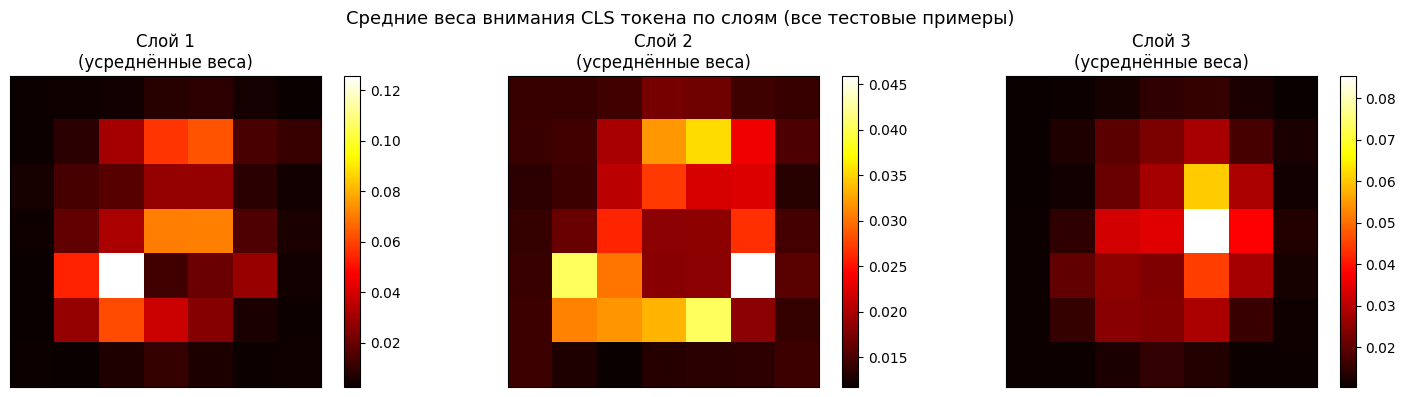

In [24]:
model.eval()
layer_attentions = defaultdict(list)

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        _ = model(images)
        
        for layer_idx, attn in enumerate(model.all_attn_weights):
            # attn имеет форму (batch, seq_len, seq_len)
            # Берём веса от CLS (индекс 0) ко всем патчам (индексы 1:)
            avg_attn = attn[:, 0, 1:].cpu().numpy()
            layer_attentions[layer_idx].append(avg_attn)

num_layers = len(layer_attentions)
fig, axes = plt.subplots(1, num_layers, figsize=(15, 4))

for layer_idx in range(num_layers):
    attn_data = np.concatenate(layer_attentions[layer_idx], axis=0)
    mean_attn = attn_data.mean(axis=0).reshape(7, 7)
    
    im = axes[layer_idx].imshow(mean_attn, cmap='hot')
    axes[layer_idx].set_title(f'Слой {layer_idx + 1}\n(усреднённые веса)')
    axes[layer_idx].set_xticks([])
    axes[layer_idx].set_yticks([])
    plt.colorbar(im, ax=axes[layer_idx])

plt.suptitle('Средние веса внимания CLS токена по слоям (все тестовые примеры)', fontsize=13)
plt.tight_layout()
plt.show()

## Выводы и интерпретация

Модель Vision Transformer достигла 86.85% точности на MNIST с 3 слоями и 4 головами внимания. Визуализация показывает иерархическое обучение: слой 1 изучает локальные детали (края, линии), слой 2 смотрит уже на регионы, слой 3 - всю картинку целиком. Белые области на картах внимания соответствуют критическим признакам: для "7" - верхняя линия, для "2" - округлая верхняя часть, для "1" - вертикальная линия в центре.

Главное преимущество трансформера перед CNN - интерпретируемость. Все взаимодействия видны одновременно. 